In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Training RNNs

## Forecasting a Time Series

In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

In [6]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [7]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Let's look at the first few months of 2019 (note that Pandas treats the range boundaries as inclusive):

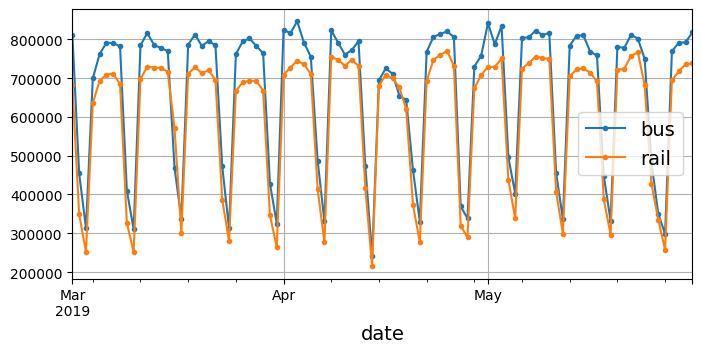

In [8]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

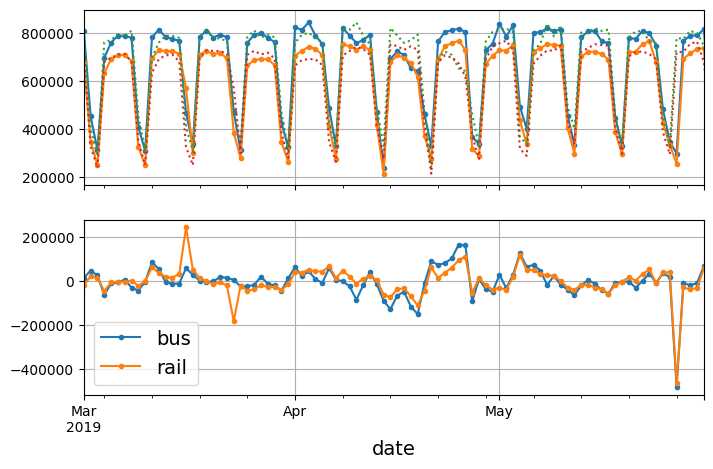

In [9]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot

plt.show()

In [10]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

Mean absolute error (MAE), also called mean absolute deviation (MAD):

In [11]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

Mean absolute percentage error (MAPE):

In [12]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Now let's look at the yearly seasonality and the long-term trends:

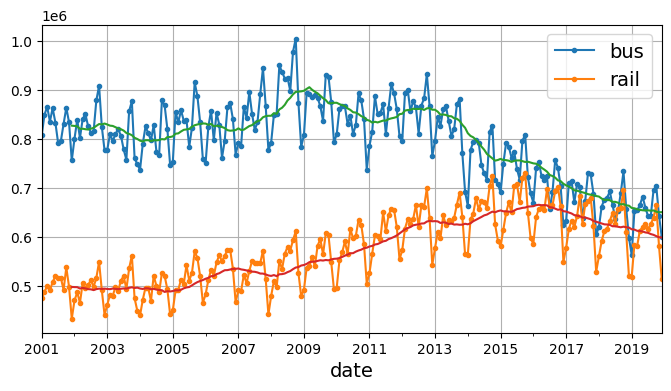

In [13]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

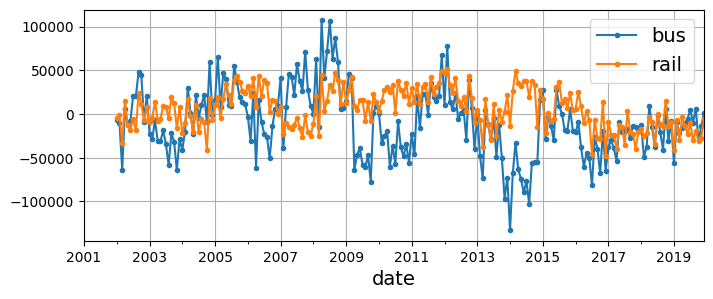

In [14]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

## Preparing the Data for Machine Learning Models

In [109]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length  # 1st index after window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

In [16]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

In [ ]:
from torch.utils.data import DataLoader

window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [18]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [ ]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
model = nn.Sequential(
	nn.Flatten(), 
	nn.Linear(window_length, 1)
).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, loss_fn, metric, train_loader,
                valid_loader, n_epochs=50)

Epoch 1/50, train loss: 0.0154, train metric: 0.1458, valid metric: 0.1235
Epoch 2/50, train loss: 0.0100, train metric: 0.1117, valid metric: 0.0996
Epoch 3/50, train loss: 0.0075, train metric: 0.0933, valid metric: 0.0795
Epoch 4/50, train loss: 0.0063, train metric: 0.0816, valid metric: 0.0668
Epoch 5/50, train loss: 0.0056, train metric: 0.0741, valid metric: 0.0609
Epoch 6/50, train loss: 0.0053, train metric: 0.0697, valid metric: 0.0550
Epoch 7/50, train loss: 0.0049, train metric: 0.0663, valid metric: 0.0545
Epoch 8/50, train loss: 0.0047, train metric: 0.0636, valid metric: 0.0493
Epoch 9/50, train loss: 0.0045, train metric: 0.0617, valid metric: 0.0457
Epoch 10/50, train loss: 0.0045, train metric: 0.0615, valid metric: 0.0437
Epoch 11/50, train loss: 0.0043, train metric: 0.0586, valid metric: 0.0453
Epoch 12/50, train loss: 0.0042, train metric: 0.0577, valid metric: 0.0420
Epoch 13/50, train loss: 0.0042, train metric: 0.0576, valid metric: 0.0403
Epoch 14/50, train lo

In [20]:
evaluate_tm(model, valid_loader, metric).item() * 1e6

37725.71310400963

## Using a Simple RNN

In [21]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

torch.manual_seed(42)
model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1).to(device)

In [22]:
# extra code – defines a utility function we'll reuse several time

def fit_and_evaluate(model, train_loader, valid_loader, lr, n_epochs=50,
                     patience=20, factor=0.1):
    loss_fn = nn.HuberLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    metric = torchmetrics.MeanAbsoluteError().to(device)
    history = train(model, optimizer, loss_fn, metric,
                    train_loader, valid_loader, n_epochs=n_epochs,
                    patience=patience, factor=factor)
    return min(history["valid_metrics"]) * 1e6

In [37]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
univar_model = univar_model.to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0523, train metric: 0.2600, valid metric: 0.2126
Epoch 2/50, train loss: 0.0174, train metric: 0.1542, valid metric: 0.1167
Epoch 3/50, train loss: 0.0135, train metric: 0.1421, valid metric: 0.1166
Epoch 4/50, train loss: 0.0106, train metric: 0.1212, valid metric: 0.1054
Epoch 5/50, train loss: 0.0075, train metric: 0.0968, valid metric: 0.0914
Epoch 6/50, train loss: 0.0060, train metric: 0.0831, valid metric: 0.0759
Epoch 7/50, train loss: 0.0055, train metric: 0.0776, valid metric: 0.0749
Epoch 8/50, train loss: 0.0051, train metric: 0.0748, valid metric: 0.0683
Epoch 9/50, train loss: 0.0047, train metric: 0.0710, valid metric: 0.0615
Epoch 10/50, train loss: 0.0047, train metric: 0.0706, valid metric: 0.0629
Epoch 11/50, train loss: 0.0047, train metric: 0.0699, valid metric: 0.0652
Epoch 12/50, train loss: 0.0046, train metric: 0.0696, valid metric: 0.0576
Epoch 13/50, train loss: 0.0045, train metric: 0.0689, valid metric: 0.0733
Epoch 14/50, train lo

30511.004850268364

In [23]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [24]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
univar_model = univar_model.to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0487, train metric: 0.2535, valid metric: 0.1329
Epoch 2/50, train loss: 0.0181, train metric: 0.1523, valid metric: 0.1268
Epoch 3/50, train loss: 0.0137, train metric: 0.1459, valid metric: 0.1377
Epoch 4/50, train loss: 0.0122, train metric: 0.1348, valid metric: 0.1184
Epoch 5/50, train loss: 0.0115, train metric: 0.1279, valid metric: 0.1255
Epoch 6/50, train loss: 0.0105, train metric: 0.1231, valid metric: 0.1130
Epoch 7/50, train loss: 0.0090, train metric: 0.1127, valid metric: 0.1018
Epoch 8/50, train loss: 0.0064, train metric: 0.0885, valid metric: 0.0781
Epoch 9/50, train loss: 0.0055, train metric: 0.0792, valid metric: 0.0682
Epoch 10/50, train loss: 0.0048, train metric: 0.0727, valid metric: 0.0662
Epoch 11/50, train loss: 0.0044, train metric: 0.0683, valid metric: 0.0585
Epoch 12/50, train loss: 0.0043, train metric: 0.0675, valid metric: 0.0618
Epoch 13/50, train loss: 0.0043, train metric: 0.0662, valid metric: 0.0691
Epoch 14/50, train lo

30659.416690468788

In [ ]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
univar_model = univar_model.to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0487, train metric: 0.2535, valid metric: 0.1329
Epoch 2/50, train loss: 0.0181, train metric: 0.1523, valid metric: 0.1268
Epoch 3/50, train loss: 0.0137, train metric: 0.1459, valid metric: 0.1377
Epoch 4/50, train loss: 0.0122, train metric: 0.1348, valid metric: 0.1184
Epoch 5/50, train loss: 0.0115, train metric: 0.1279, valid metric: 0.1255
Epoch 6/50, train loss: 0.0105, train metric: 0.1231, valid metric: 0.1130
Epoch 7/50, train loss: 0.0090, train metric: 0.1127, valid metric: 0.1018
Epoch 8/50, train loss: 0.0064, train metric: 0.0885, valid metric: 0.0781
Epoch 9/50, train loss: 0.0055, train metric: 0.0792, valid metric: 0.0682
Epoch 10/50, train loss: 0.0048, train metric: 0.0727, valid metric: 0.0662
Epoch 11/50, train loss: 0.0044, train metric: 0.0683, valid metric: 0.0585
Epoch 12/50, train loss: 0.0043, train metric: 0.0675, valid metric: 0.0618
Epoch 13/50, train loss: 0.0043, train metric: 0.0662, valid metric: 0.0691
Epoch 14/50, train lo

30659.500509500504

## Deep RNNs

In [31]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layer, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layer, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

model = DeepRnnModel(
	input_size=1, 
	hidden_size=1, 
	num_layer = 1,
	output_size=1
	)

In [28]:
X_batch, y_batch = next(iter(train_loader))
X_batch.shape, y_batch.shape

(torch.Size([32, 56, 1]), torch.Size([32, 1]))

In [53]:
model = DeepRnnModel(
	input_size=1, 
	hidden_size=10, 
	num_layer = 3,
	output_size=1
	).to(device)

model

DeepRnnModel(
  (rnn): RNN(1, 10, num_layers=3, batch_first=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
)

In [54]:
torch.manual_seed(42)
fit_and_evaluate(model, train_loader, valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0544, train metric: 0.2659, valid metric: 0.1864
Epoch 2/50, train loss: 0.0207, train metric: 0.1705, valid metric: 0.1321
Epoch 3/50, train loss: 0.0174, train metric: 0.1571, valid metric: 0.1780
Epoch 4/50, train loss: 0.0171, train metric: 0.1596, valid metric: 0.1188
Epoch 5/50, train loss: 0.0161, train metric: 0.1545, valid metric: 0.1327
Epoch 6/50, train loss: 0.0129, train metric: 0.1314, valid metric: 0.0861
Epoch 7/50, train loss: 0.0084, train metric: 0.1014, valid metric: 0.0738
Epoch 8/50, train loss: 0.0060, train metric: 0.0806, valid metric: 0.0614
Epoch 9/50, train loss: 0.0054, train metric: 0.0742, valid metric: 0.0693
Epoch 10/50, train loss: 0.0050, train metric: 0.0709, valid metric: 0.0604
Epoch 11/50, train loss: 0.0049, train metric: 0.0688, valid metric: 0.0566
Epoch 12/50, train loss: 0.0049, train metric: 0.0678, valid metric: 0.0537
Epoch 13/50, train loss: 0.0047, train metric: 0.0679, valid metric: 0.0716
Epoch 14/50, train lo

30781.399458646774

In [81]:
# from sklearn.preprocessing import OneHotEncoder
# enc = OneHotEncoder(sparse_output=False)
# enc.fit_transform(df[['day_type']])

In [80]:
df['next_day_type'] = df['day_type'].shift(-1)
df

,day_type,bus,rail,next_day_type
date,,,,
2001-01-01,U,297192,126455,W
2001-01-02,W,780827,501952,W
2001-01-03,W,824923,536432,W
2001-01-04,W,870021,550011,W
2001-01-05,W,890426,557917,A
...,...,...,...,...
2021-11-26,W,257700,189694,A
2021-11-27,A,237839,187065,U
2021-11-28,U,184817,147830,W


In [93]:
df_mulvar = df[['rail', 'bus']] / 1e6
df_mulvar = pd.concat(
	[
		df_mulvar,
		pd.get_dummies(df['next_day_type'], dtype='float')
	], axis=1)
df_mulvar

,rail,bus,A,U,W
date,,,,,
2001-01-01,0.126455,0.297192,0.0,0.0,1.0
2001-01-02,0.501952,0.780827,0.0,0.0,1.0
2001-01-03,0.536432,0.824923,0.0,0.0,1.0
2001-01-04,0.550011,0.870021,0.0,0.0,1.0
2001-01-05,0.557917,0.890426,1.0,0.0,0.0
...,...,...,...,...,...
2021-11-26,0.189694,0.257700,1.0,0.0,0.0
2021-11-27,0.187065,0.237839,0.0,1.0,0.0
2021-11-28,0.147830,0.184817,0.0,0.0,1.0


In [94]:
mulvar_train = torch.FloatTensor(df_mulvar["2016-01":"2018-12"].values)
mulvar_valid = torch.FloatTensor(df_mulvar["2019-01":"2019-05"].values)
mulvar_test = torch.FloatTensor(df_mulvar["2019-06":].values)

In [101]:
# mulvar_train[0:56]
mulvar_train[56][:1]

tensor([0.7500])

In [ ]:
# class MulvarSeriesDataset(torch.utils.data.Dataset):
#     def __init__(self, series, window_length):
#         self.series = series
#         self.window_length = window_length

#     def __len__(self):
#         return len(self.series) - self.window_length

#     def __getitem__(self, idx):
#         if idx >= len(self):
#             raise IndexError("dataset index out of range")
#         end = idx + self.window_length  # 1st index after window
#         window = self.series[idx : end]
#         target = self.series[end]
#         return window, target[:1]

class MulvarSeriesDataset(TimeSeriesDataset):
	def __getitem__(self, idx):
		window, target = super().__getitem__(idx)
		return window, target[:1]

window_length = 56
mulvar_train_set = MulvarSeriesDataset(mulvar_train, window_length)
mulvar_train_loader = DataLoader(mulvar_train_set, batch_size=32, shuffle=True)
mulvar_valid_set = MulvarSeriesDataset(mulvar_valid, window_length)
mulvar_valid_loader = DataLoader(mulvar_valid_set, batch_size=32)
mulvar_test_set = MulvarSeriesDataset(mulvar_test, window_length)
mulvar_test_loader = DataLoader(mulvar_test_set, batch_size=32)

In [119]:
model = DeepRnnModel(
	input_size=5, 
	hidden_size=10, 
	num_layer = 3,
	output_size=1
	).to(device)

model

DeepRnnModel(
  (rnn): RNN(5, 10, num_layers=3, batch_first=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
)

In [120]:
torch.manual_seed(42)
fit_and_evaluate(model, mulvar_train_loader, mulvar_valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0853, train metric: 0.3262, valid metric: 0.1979
Epoch 2/50, train loss: 0.0115, train metric: 0.1200, valid metric: 0.0597
Epoch 3/50, train loss: 0.0044, train metric: 0.0725, valid metric: 0.0372
Epoch 4/50, train loss: 0.0031, train metric: 0.0575, valid metric: 0.0269
Epoch 5/50, train loss: 0.0024, train metric: 0.0476, valid metric: 0.0296
Epoch 6/50, train loss: 0.0021, train metric: 0.0431, valid metric: 0.0340
Epoch 7/50, train loss: 0.0020, train metric: 0.0419, valid metric: 0.0287
Epoch 8/50, train loss: 0.0019, train metric: 0.0410, valid metric: 0.0528
Epoch 9/50, train loss: 0.0020, train metric: 0.0433, valid metric: 0.0532
Epoch 10/50, train loss: 0.0018, train metric: 0.0400, valid metric: 0.0279
Epoch 11/50, train loss: 0.0017, train metric: 0.0398, valid metric: 0.0302
Epoch 12/50, train loss: 0.0017, train metric: 0.0387, valid metric: 0.0293
Epoch 13/50, train loss: 0.0017, train metric: 0.0399, valid metric: 0.0323
Epoch 14/50, train lo

23426.121100783348

In [121]:
multask_train = torch.FloatTensor(df_mulvar["2016-01":"2018-12"].values)
multask_valid = torch.FloatTensor(df_mulvar["2019-01":"2019-05"].values)
multask_test = torch.FloatTensor(df_mulvar["2019-06":].values)

class MulTaskSeriesDataset(TimeSeriesDataset):
	def __getitem__(self, idx):
		window, target = super().__getitem__(idx)
		return window, target[:2]

window_length = 56
multask_train_set = MulTaskSeriesDataset(multask_train, window_length)
multask_train_loader = DataLoader(multask_train_set, batch_size=32, shuffle=True)
multask_valid_set = MulTaskSeriesDataset(multask_valid, window_length)
multask_valid_loader = DataLoader(multask_valid_set, batch_size=32)
multask_test_set = MulTaskSeriesDataset(multask_test, window_length)
multask_test_loader = DataLoader(multask_test_set, batch_size=32)

In [122]:
model = DeepRnnModel(
	input_size=5, 
	hidden_size=10, 
	num_layer = 3,
	output_size=2
	).to(device)

model

DeepRnnModel(
  (rnn): RNN(5, 10, num_layers=3, batch_first=True)
  (output): Linear(in_features=10, out_features=2, bias=True)
)

In [124]:
torch.manual_seed(42)
fit_and_evaluate(model, multask_train_loader, multask_valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0363, train metric: 0.2033, valid metric: 0.1048
Epoch 2/50, train loss: 0.0068, train metric: 0.0923, valid metric: 0.0612
Epoch 3/50, train loss: 0.0029, train metric: 0.0556, valid metric: 0.0440
Epoch 4/50, train loss: 0.0023, train metric: 0.0484, valid metric: 0.0371
Epoch 5/50, train loss: 0.0020, train metric: 0.0444, valid metric: 0.0321
Epoch 6/50, train loss: 0.0020, train metric: 0.0443, valid metric: 0.0301
Epoch 7/50, train loss: 0.0019, train metric: 0.0435, valid metric: 0.0327
Epoch 8/50, train loss: 0.0018, train metric: 0.0416, valid metric: 0.0365
Epoch 9/50, train loss: 0.0018, train metric: 0.0423, valid metric: 0.0374
Epoch 10/50, train loss: 0.0017, train metric: 0.0406, valid metric: 0.0374
Epoch 11/50, train loss: 0.0017, train metric: 0.0410, valid metric: 0.0320
Epoch 12/50, train loss: 0.0016, train metric: 0.0406, valid metric: 0.0330
Epoch 13/50, train loss: 0.0015, train metric: 0.0390, valid metric: 0.0344
Epoch 14/50, train lo

27528.638020157814

In [130]:
X_batch, y_batch = next(iter(multask_test_loader))
X_batch.shape, y_batch.shape

(torch.Size([32, 56, 5]), torch.Size([32, 2]))

In [134]:
y_pred = model(X_batch)
y_pred

tensor([[0.3957, 0.4291],
        [0.3111, 0.3393],
        [0.6944, 0.7579],
        [0.6901, 0.7580],
        [0.7012, 0.7561],
        [0.7148, 0.7611],
        [0.7154, 0.7553],
        [0.4314, 0.4655],
        [0.3372, 0.3658],
        [0.7287, 0.7926],
        [0.7246, 0.7922],
        [0.7138, 0.7684],
        [0.7228, 0.7690],
        [0.6977, 0.7382],
        [0.3952, 0.4285],
        [0.3104, 0.3387],
        [0.6918, 0.7552],
        [0.6879, 0.7558],
        [0.6859, 0.7408],
        [0.6924, 0.7385],
        [0.6723, 0.7122],
        [0.3715, 0.4040],
        [0.2912, 0.3191],
        [0.6650, 0.7275],
        [0.6934, 0.7612],
        [0.6703, 0.7254],
        [0.7025, 0.7481],
        [0.6914, 0.7313],
        [0.3927, 0.4257],
        [0.3095, 0.3377],
        [0.6965, 0.7597],
        [0.6978, 0.7655]], grad_fn=<AddmmBackward0>)